In [209]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scikit_posthocs as sp
import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import chi2_contingency
from scipy.stats import kruskal


In [210]:

df = pd.read_csv("Final_Cleaned_Absences.csv", sep=",")


In [211]:
df.shape
df.columns


Index(['intitule_cours', 'type_cours', 'code_cours', 'date', 'date_only',
       'heure', 'jour_semaine', 'civilité', 'code_civilité', 'groupe_eleve',
       'code_eleve', 'groupes'],
      dtype='object')

In [212]:
df = df.copy()

df["session_id"] = (
    df["intitule_cours"].astype(str) + " | " +
    df["type_cours"].astype(str) + " | " +
    df["groupe_eleve"].astype(str) + " | " +
    df["date"].astype(str) + " | " +
    df["heure"].astype(str)
)


In [213]:
sessions = (
    df
    .groupby(["session_id", "heure"], as_index=False)
    .size()
    .rename(columns={"size": "n_abs"})
)

sessions.head()


,session_id,heure,n_abs
0,Algo.et Types abstrait 1 | CMTD | G1 | 03/11/2...,11:30:00,4
1,Algo.et Types abstrait 1 | CMTD | G1 | 03/12/2...,08:45:00,3
2,Algo.et Types abstrait 1 | CMTD | G1 | 04/11/2...,08:00:00,6
3,Algo.et Types abstrait 1 | CMTD | G1 | 08/10/2...,09:45:00,1
4,Algo.et Types abstrait 1 | CMTD | G1 | 13/10/2...,15:45:00,4


In [214]:
sessions["heure"].value_counts().sort_index()


,count
heure,
08:00:00,42
08:45:00,5
09:45:00,55
10:30:00,4
11:15:00,1
11:30:00,21
14:00:00,26
14:30:00,1
15:45:00,21


/tmp/ipython-input-286533347.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_hour, labels=hours, showfliers=True)


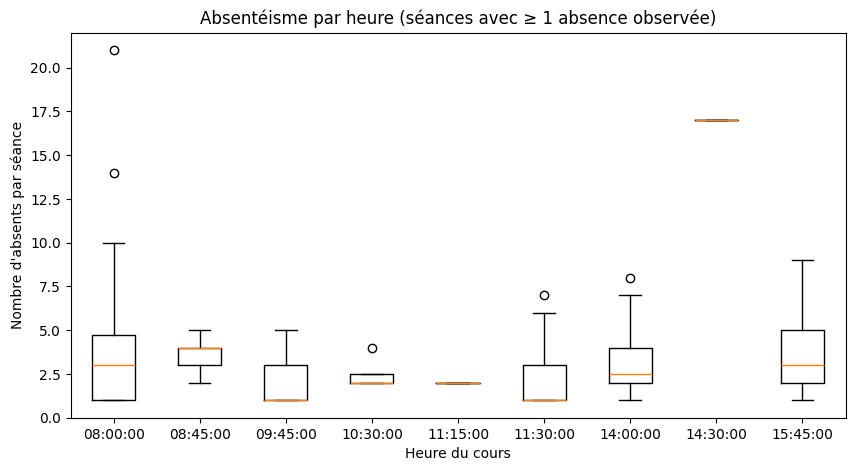

In [215]:

hours = sorted(sessions["heure"].unique())
data_by_hour = [
    sessions.loc[sessions["heure"] == h, "n_abs"].values
    for h in hours
]

plt.figure(figsize=(10,5))
plt.boxplot(data_by_hour, labels=hours, showfliers=True)
plt.title("Absentéisme par heure (séances avec ≥ 1 absence observée)")
plt.xlabel("Heure du cours")
plt.ylabel("Nombre d'absents par séance")
plt.show()


Tests statistiques robuste


In [216]:
counts = sessions["heure"].value_counts()
robust_hours = counts[counts >= 10].index

sessions_robust = sessions[sessions["heure"].isin(robust_hours)]
#on ne garde que les sessions avec plus de 10 absence (ce qui correspond aux crenaux classique de cours)

In [217]:
groups = [
    sessions_robust.loc[sessions_robust["heure"] == h, "n_abs"].values
    for h in robust_hours
]

stat, p = kruskal(*groups)
stat, p


(np.float64(20.480984592534654), np.float64(0.00040123243741483765))

/tmp/ipython-input-3058392160.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(sessions["heure"].astype(str))
/tmp/ipython-input-3058392160.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  + pd.to_datetime(sessions["heure"].astype(str)).dt.minute


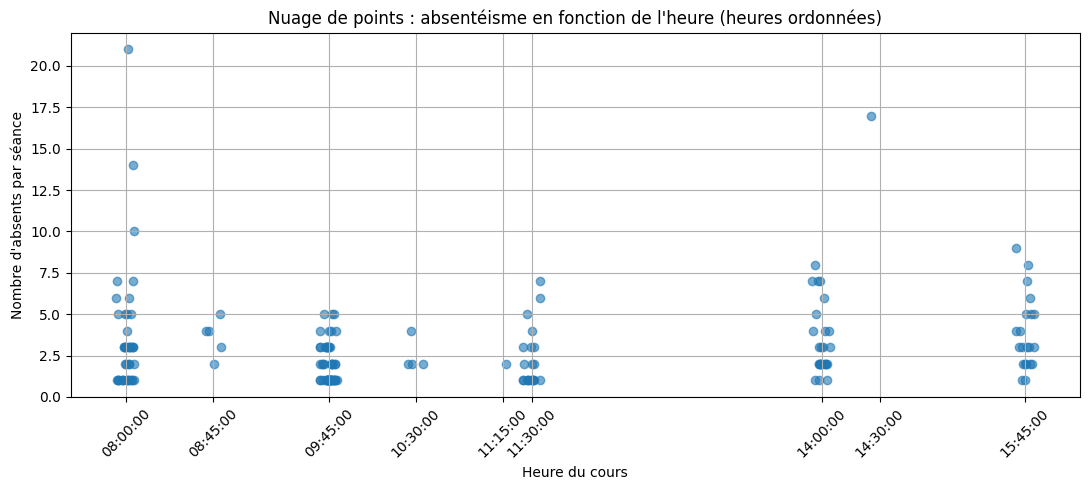

In [218]:

# On part du DataFrame 'sessions'
# colonnes attendues : 'heure' , 'n_abs'

# Conversion de l'heure en minutes depuis minuit (pour trier correctement)
sessions["heure_min"] = (
    pd.to_datetime(sessions["heure"].astype(str))
    .dt.hour * 60
    + pd.to_datetime(sessions["heure"].astype(str)).dt.minute
)

sessions_sorted = sessions.sort_values("heure_min")

x_jitter = (
    sessions_sorted["heure_min"]
    + np.random.uniform(-5, 5, size=len(sessions_sorted))  # jitter en minutes
)

unique_hours = sessions_sorted.drop_duplicates("heure_min")

# Nuage de points
plt.figure(figsize=(11,5))
plt.scatter(
    x_jitter,
    sessions_sorted["n_abs"],
    alpha=0.6
)

plt.title("Nuage de points : absentéisme en fonction de l'heure (heures ordonnées)")
plt.xlabel("Heure du cours")
plt.ylabel("Nombre d'absents par séance")

plt.xticks(
    unique_hours["heure_min"],
    unique_hours["heure"],
    rotation=45
)

plt.grid(True)
plt.tight_layout()
plt.show()



In [219]:

# Catégoriser l'absentéisme (binaire) -> nécessaire pour un test du χ²
# seuil = médiane
threshold = sessions["n_abs"].median()
sessions = sessions.copy()
sessions["abs_cat"] = np.where(sessions["n_abs"] > threshold, "Fort", "Faible")

# Regrouper les heures trop rares pour stabiliser le χ²
# Ici on regroupe en "AUTRES" les heures avec peu de séances observées.
min_sessions_per_hour = 5
hour_counts = sessions["heure"].value_counts()
rare_hours = hour_counts[hour_counts < min_sessions_per_hour].index

sessions["heure_cat"] = sessions["heure"].astype(str)
sessions.loc[sessions["heure"].isin(rare_hours), "heure_cat"] = "AUTRES"

# Table de contingence (heures x niveau d'absentéisme)
cont = pd.crosstab(sessions["heure_cat"], sessions["abs_cat"])
print("Table de contingence (observée) :")
display(cont)

# Test du χ² d'indépendance
chi2, p, dof, expected = chi2_contingency(cont)
print(f"\nChi2 = {chi2:.4f} | dof = {dof} | p-value = {p:.6g}")

# Vérification des effectifs attendus (validité)
expected_df = pd.DataFrame(expected, index=cont.index, columns=cont.columns)
low_expected = (expected_df < 5).sum().sum()
total_cells = expected_df.size
print(f"Cellules avec effectif attendu < 5 : {low_expected}/{total_cells}")

# Taille d'effet : Cramér's V
n = cont.to_numpy().sum()
r, c = cont.shape
cramers_v = np.sqrt((chi2 / n) / (min(r-1, c-1)))
print(f"Cramér's V = {cramers_v:.4f}")

# Conclusion automatique
alpha = 0.05
if p < alpha:
    print("\n Conclusion: on rejette l'indépendance -> l'heure est associée au niveau d'absentéisme.")
else:
    print("\n Conclusion: on ne rejette pas l'indépendance -> pas de lien détecté (avec ce découpage).")


Table de contingence (observée) :


abs_cat,Faible,Fort
heure_cat,,
08:00:00,19,23
08:45:00,1,4
09:45:00,38,17
11:30:00,14,7
14:00:00,13,13
15:45:00,7,14
AUTRES,4,2



Chi2 = 14.1952 | dof = 6 | p-value = 0.0275297
Cellules avec effectif attendu < 5 : 4/14
Cramér's V = 0.2840

 Conclusion: on rejette l'indépendance -> l'heure est associée au niveau d'absentéisme.


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  n_abs   No. Observations:                  176
Model:                            GLM   Df Residuals:                      167
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -359.16
Date:                Wed, 14 Jan 2026   Deviance:                       235.22
Time:                        09:46:16   Pearson chi2:                     298.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3204
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

/tmp/ipython-input-3748037720.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sessions["heure_min"] = (pd.to_datetime(sessions["heure_str"]).dt.hour * 60
/tmp/ipython-input-3748037720.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  + pd.to_datetime(sessions["heure_str"]).dt.minute)


,IRR,CI_low,CI_high
Intercept,3.619048,3.087114,4.242637
C(heure_str)[T.08:45:00],0.994737,0.610283,1.621382
C(heure_str)[T.09:45:00],0.547608,0.428187,0.700334
C(heure_str)[T.10:30:00],0.690789,0.364300,1.309883
C(heure_str)[T.11:15:00],0.552632,0.136961,2.229836
C(heure_str)[T.11:30:00],0.631579,0.456559,0.873692
C(heure_str)[T.14:00:00],0.924595,0.710426,1.203329
C(heure_str)[T.14:30:00],4.697368,2.845569,7.754256
C(heure_str)[T.15:45:00],1.052632,0.802977,1.379907



Dispersion ratio (deviance/df_resid) = 1.409


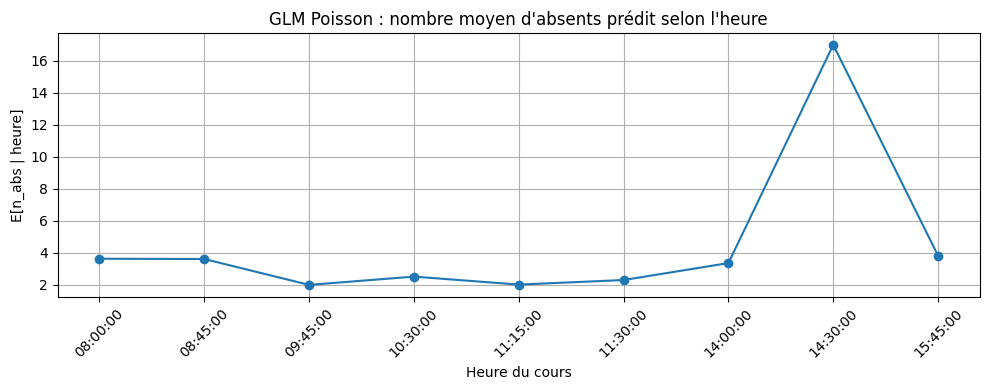

In [220]:
df = df.copy()

df["session_id"] = (
    df["intitule_cours"].astype(str) + " | " +
    df["type_cours"].astype(str) + " | " +
    df["groupe_eleve"].astype(str) + " | " +
    df["date"].astype(str) + " | " +
    df["heure"].astype(str)
)

sessions = (
    df.groupby(["session_id", "heure", "type_cours"], as_index=False)
      .size()
      .rename(columns={"size": "n_abs"})
)


sessions["n_abs"] = sessions["n_abs"].astype(int)

sessions["heure_str"] = sessions["heure"].astype(str)
sessions["heure_min"] = (pd.to_datetime(sessions["heure_str"]).dt.hour * 60
                         + pd.to_datetime(sessions["heure_str"]).dt.minute)
ordered_hours = (sessions[["heure_str", "heure_min"]]
                 .drop_duplicates()
                 .sort_values("heure_min")["heure_str"].tolist())

sessions["heure_str"] = pd.Categorical(sessions["heure_str"], categories=ordered_hours, ordered=True)


formula = "n_abs ~ C(heure_str)"


# Fit GLM Poisson
model = smf.glm(formula=formula, data=sessions, family=sm.families.Poisson()).fit()

print(model.summary())

#  Interprétation pratique : Incidence Rate Ratios (IRR = exp(beta))
irr = np.exp(model.params)
irr_ci = np.exp(model.conf_int())
irr_table = pd.DataFrame({
    "IRR": irr,
    "CI_low": irr_ci[0],
    "CI_high": irr_ci[1]
})
print("\nIncidence Rate Ratios (exp(coef)) :")
display(irr_table)

# Vérifier la sur-dispersion
# ratio ~ 1 : Poisson OK ; >> 1 : sur-dispersion
dispersion_ratio = model.deviance / model.df_resid
print(f"\nDispersion ratio (deviance/df_resid) = {dispersion_ratio:.3f}")

#  Prédictions moyennes par heure
pred_df = pd.DataFrame({"heure_str": pd.Categorical(ordered_hours, categories=ordered_hours, ordered=True)})
if "type_cours" in formula:
    pred_df["type_cours"] = sessions["type_cours"].mode().iloc[0]  #

pred_df["pred_mean_abs"] = model.predict(pred_df)

plt.figure(figsize=(10,4))
plt.plot(pred_df["heure_str"].astype(str), pred_df["pred_mean_abs"], marker="o")
plt.xticks(rotation=45)
plt.title("GLM Poisson : nombre moyen d'absents prédit selon l'heure")
plt.xlabel("Heure du cours")
plt.ylabel("E[n_abs | heure]")
plt.grid(True)
plt.tight_layout()
plt.show()


In [221]:
df = df.copy()
df["session_id"] = (
    df["intitule_cours"].astype(str) + " | " +
    df["type_cours"].astype(str) + " | " +
    df["groupe_eleve"].astype(str) + " | " +
    df["date"].astype(str) + " | " +
    df["heure"].astype(str)
)

sessions = (
    df.groupby(["session_id", "heure", "jour_semaine", "type_cours"], as_index=False)
      .size()
      .rename(columns={"size": "n_abs"})
)

jours_ordre = ["lundi", "mardi", "mercredi", "jeudi", "vendredi"]

sessions["jour_semaine"] = sessions["jour_semaine"].astype(str).str.lower().str.strip()
sessions["jour_semaine"] = pd.Categorical(
    sessions["jour_semaine"],
    categories=jours_ordre,
    ordered=True
)

print(sessions.columns)
sessions.head()



Index(['session_id', 'heure', 'jour_semaine', 'type_cours', 'n_abs'], dtype='object')


,session_id,heure,jour_semaine,type_cours,n_abs
0,Algo.et Types abstrait 1 | CMTD | G1 | 03/11/2...,11:30:00,lundi,CMTD,4
1,Algo.et Types abstrait 1 | CMTD | G1 | 03/12/2...,08:45:00,mercredi,CMTD,3
2,Algo.et Types abstrait 1 | CMTD | G1 | 04/11/2...,08:00:00,mardi,CMTD,6
3,Algo.et Types abstrait 1 | CMTD | G1 | 08/10/2...,09:45:00,mercredi,CMTD,1
4,Algo.et Types abstrait 1 | CMTD | G1 | 13/10/2...,15:45:00,lundi,CMTD,4


In [222]:
desc_jour = (
    sessions.groupby("jour_semaine")["n_abs"]
    .agg(n_seances="count", mean="mean", median="median", std="std")
)
desc_jour


/tmp/ipython-input-138442939.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sessions.groupby("jour_semaine")["n_abs"]


,n_seances,mean,median,std
jour_semaine,,,,
lundi,49,2.489796,2.0,1.582751
mardi,53,2.849057,2.0,3.444037
mercredi,42,3.428571,3.0,2.872433
jeudi,9,2.111111,1.0,1.691482
vendredi,23,3.782609,3.0,2.411271


<Figure size 800x400 with 0 Axes>

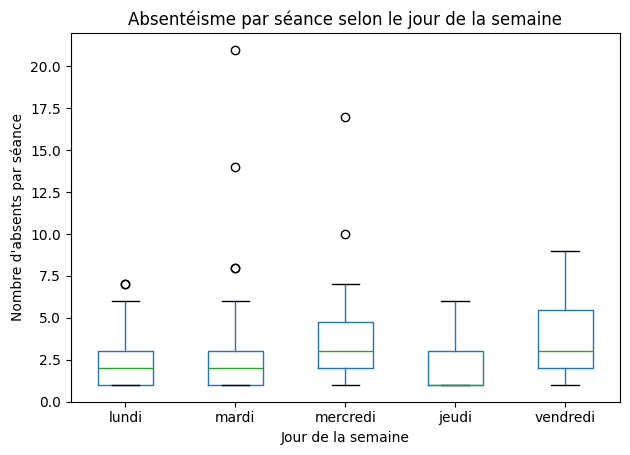

In [223]:
plt.figure(figsize=(8,4))

sessions.boxplot(
    column="n_abs",
    by="jour_semaine",
    grid=False
)

plt.title("Absentéisme par séance selon le jour de la semaine")
plt.suptitle("")
plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre d'absents par séance")
plt.tight_layout()
plt.show()


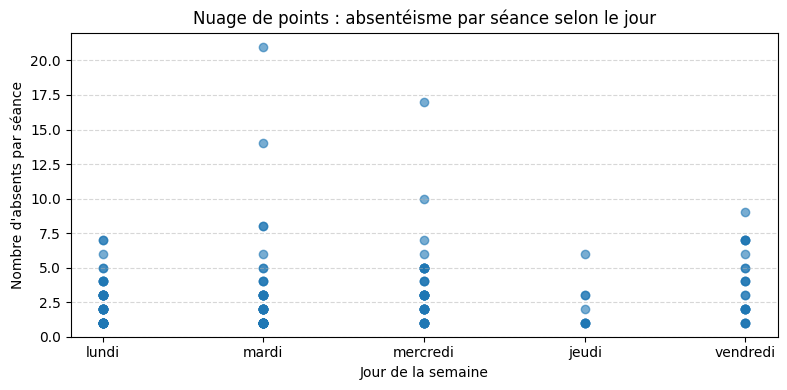

In [224]:
jour_to_num = {jour: i for i, jour in enumerate(sessions["jour_semaine"].cat.categories)}

x = sessions["jour_semaine"].map(jour_to_num)
y = sessions["n_abs"]

plt.figure(figsize=(8,4))
plt.scatter(x, y, alpha=0.6)

plt.xticks(
    ticks=list(jour_to_num.values()),
    labels=list(jour_to_num.keys())
)

plt.title("Nuage de points : absentéisme par séance selon le jour")
plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre d'absents par séance")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [225]:
# Seuil = médiane
threshold = sessions["n_abs"].median()

sessions = sessions.copy()
sessions["abs_cat"] = np.where(
    sessions["n_abs"] > threshold,
    "Fort",
    "Faible"
)

sessions[["n_abs", "abs_cat"]].head()


,n_abs,abs_cat
0,4,Fort
1,3,Fort
2,6,Fort
3,1,Faible
4,4,Fort


In [226]:
cont_jour = pd.crosstab(
    sessions["jour_semaine"],
    sessions["abs_cat"]
)

cont_jour


abs_cat,Faible,Fort
jour_semaine,,
lundi,28,21
mardi,34,19
mercredi,18,24
jeudi,6,3
vendredi,10,13


In [227]:
cont_jour.sum(axis=1)


,0
jour_semaine,
lundi,49
mardi,53
mercredi,42
jeudi,9
vendredi,23


In [228]:
chi2, p, dof, expected = chi2_contingency(cont_jour)

print(f"Chi2 = {chi2:.3f}")
print(f"ddl = {dof}")
print(f"p-value = {p:.5f}")


Chi2 = 6.090
ddl = 4
p-value = 0.19256


In [229]:
n = cont_jour.to_numpy().sum()
r, c = cont_jour.shape

cramers_v = np.sqrt((chi2 / n) / (min(r - 1, c - 1)))
print(f"Cramér's V = {cramers_v:.3f}")


Cramér's V = 0.186


In [230]:
sessions = sessions.copy()
sessions["n_abs"] = sessions["n_abs"].astype(int)

# Modèle GLM Poisson : jour de la semaine
model_jour = smf.glm(
    formula="n_abs ~ C(jour_semaine)",
    data=sessions,
    family=sm.families.Poisson()
).fit()

print(model_jour.summary())

# IRR
irr = np.exp(model_jour.params)
irr_ci = np.exp(model_jour.conf_int())

irr_table = pd.DataFrame({
    "IRR": irr,
    "CI_low": irr_ci[0],
    "CI_high": irr_ci[1]
})

irr_table


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  n_abs   No. Observations:                  176
Model:                            GLM   Df Residuals:                      171
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -386.00
Date:                Wed, 14 Jan 2026   Deviance:                       288.90
Time:                        09:46:16   Pearson chi2:                     408.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.07812
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

,IRR,CI_low,CI_high
Intercept,2.489796,2.084969,2.973226
C(jour_semaine)[T.mardi],1.144293,0.901399,1.452639
C(jour_semaine)[T.mercredi],1.377049,1.081956,1.752626
C(jour_semaine)[T.jeudi],0.847905,0.522892,1.374936
C(jour_semaine)[T.vendredi],1.519244,1.153940,2.000194


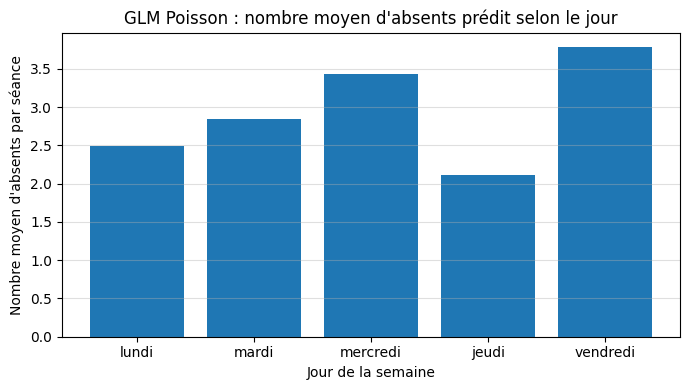

In [231]:
# Prédictions moyennes par jour
pred_df = pd.DataFrame({
    "jour_semaine": sessions["jour_semaine"].cat.categories
})

pred_df["mean_pred"] = model_jour.predict(pred_df)

plt.figure(figsize=(7,4))
plt.bar(pred_df["jour_semaine"], pred_df["mean_pred"])
plt.title("GLM Poisson : nombre moyen d'absents prédit selon le jour")
plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre moyen d'absents par séance")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


In [232]:
df = df.copy()

df["session_id"] = (
    df["intitule_cours"].astype(str) + " | " +
    df["type_cours"].astype(str) + " | " +
    df["groupe_eleve"].astype(str) + " | " +
    df["date"].astype(str) + " | " +
    df["heure"].astype(str)
)

sessions = (
    df.groupby(
        ["session_id", "date", "heure", "jour_semaine", "type_cours"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "n_abs"})
)

print(sessions.columns)
sessions.head()


Index(['session_id', 'date', 'heure', 'jour_semaine', 'type_cours', 'n_abs'], dtype='object')


,session_id,date,heure,jour_semaine,type_cours,n_abs
0,Algo.et Types abstrait 1 | CMTD | G1 | 03/11/2...,03/11/2025 11:30,11:30:00,lundi,CMTD,4
1,Algo.et Types abstrait 1 | CMTD | G1 | 03/12/2...,03/12/2025 08:45,08:45:00,mercredi,CMTD,3
2,Algo.et Types abstrait 1 | CMTD | G1 | 04/11/2...,04/11/2025 08:00,08:00:00,mardi,CMTD,6
3,Algo.et Types abstrait 1 | CMTD | G1 | 08/10/2...,08/10/2025 09:45,09:45:00,mercredi,CMTD,1
4,Algo.et Types abstrait 1 | CMTD | G1 | 13/10/2...,13/10/2025 15:45,15:45:00,lundi,CMTD,4


In [233]:
sessions["date"] = (
    sessions["date"]
    .astype(str)
    .str.strip()
)

sessions["date"] = pd.to_datetime(
    sessions["date"],
    dayfirst=True,
    errors="coerce"
)

print("NaT dans date:", sessions["date"].isna().sum())
display(sessions.loc[sessions["date"].isna(), ["session_id", "date"]].head(10))

sessions["semaine"] = sessions["date"].dt.isocalendar().week.astype(int)
sessions[["date", "semaine"]].head()


NaT dans date: 0


,session_id,date


,date,semaine
0,2025-11-03 11:30:00,45
1,2025-12-03 08:45:00,49
2,2025-11-04 08:00:00,45
3,2025-10-08 09:45:00,41
4,2025-10-13 15:45:00,42


In [234]:
desc_semaine = (
    sessions
    .groupby("semaine")["n_abs"]
    .agg(
        n_seances="count",
        mean="mean",
        median="median",
        std="std"
    )
)

desc_semaine.head()


,n_seances,mean,median,std
semaine,,,,
37,3,1.333333,1.0,0.577350
38,13,3.384615,2.0,4.213836
39,11,1.909091,1.0,1.221028
40,14,2.642857,2.0,2.023217
41,19,1.736842,1.0,1.045738


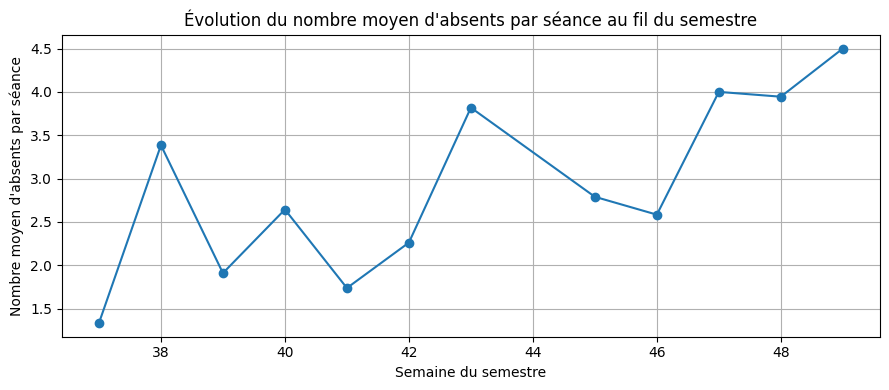

In [235]:
plt.figure(figsize=(9,4))
plt.plot(
    desc_semaine.index,
    desc_semaine["mean"],
    marker="o"
)

plt.title("Évolution du nombre moyen d'absents par séance au fil du semestre")
plt.xlabel("Semaine du semestre")
plt.ylabel("Nombre moyen d'absents par séance")
plt.grid(True)
plt.tight_layout()
plt.show()


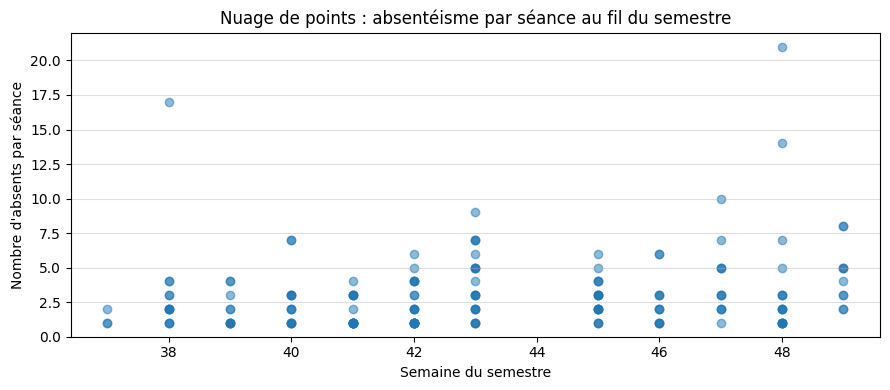

In [236]:
plt.figure(figsize=(9,4))
plt.scatter(
    sessions["semaine"],
    sessions["n_abs"],
    alpha=0.5
)

plt.title("Nuage de points : absentéisme par séance au fil du semestre")
plt.xlabel("Semaine du semestre")
plt.ylabel("Nombre d'absents par séance")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


In [237]:

rho, p_spear = spearmanr(
    sessions["semaine"],
    sessions["n_abs"]
)

print(f"Spearman rho = {rho:.3f}")
print(f"p-value = {p_spear:.5f}")


Spearman rho = 0.253
p-value = 0.00070


In [238]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model_sem = smf.glm(
    formula="n_abs ~ semaine",
    data=sessions,
    family=sm.families.Poisson()
).fit()

print(model_sem.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  n_abs   No. Observations:                  176
Model:                            GLM   Df Residuals:                      174
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -383.83
Date:                Wed, 14 Jan 2026   Deviance:                       284.57
Time:                        09:46:17   Pearson chi2:                     400.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1005
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3413      0.570     -2.354      0.0

In [239]:
def build_design_matrix_strict(df, features_cat, features_num):
    X_cat = pd.get_dummies(df[features_cat].astype(str), drop_first=True) if features_cat else None

    X_num = df[features_num].copy() if features_num else None
    if X_num is not None:
        for col in features_num:
            X_num[col] = pd.to_numeric(X_num[col], errors="coerce")
        X_num = X_num.astype(float)

    parts = [p for p in [X_cat, X_num] if p is not None]
    X = pd.concat(parts, axis=1)

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)
    X = sm.add_constant(X, has_constant="add")
    return X

def backward_logit_strict(df, y_col, features_cat, features_num, p_remove=0.10, verbose=True):
    y = pd.to_numeric(df[y_col], errors="coerce").fillna(0).astype(int)

    X = build_design_matrix_strict(df, features_cat, features_num)

    while True:
        model = sm.Logit(y, X).fit(disp=0)
        pvals = model.pvalues.drop("const", errors="ignore")

        pvals = pvals.replace([np.inf, -np.inf], np.nan).dropna()
        if pvals.empty:
            return model, X

        worst_p = pvals.max()
        worst_var = pvals.idxmax()

        if verbose:
            print(f"Step: AIC={model.aic:.2f} | worst_p={worst_p:.3f} | drop={worst_var}")

        if worst_p <= p_remove:
            return model, X

        if X.shape[1] <= 2:
            return model, X

        X = X.drop(columns=[worst_var], errors="ignore")


df_bw = sessions.copy()
df_bw["heure"] = df_bw["heure"].astype(str)
df_bw["jour_semaine"] = df_bw["jour_semaine"].astype(str)
df_bw["semaine"] = pd.to_numeric(df_bw["semaine"], errors="coerce")


threshold = df_bw["n_abs"].median()
df_bw["y_bin"] = (df_bw["n_abs"] > threshold).astype(int)

# ---------------------------
# Backward selection
# ---------------------------
model_bw, X_bw = backward_logit_strict(
    df_bw,
    y_col="y_bin",
    features_cat=["heure", "jour_semaine"],
    features_num=["semaine"],
    p_remove=0.10,
    verbose=True
)

print(model_bw.summary())

params = model_bw.params
conf = model_bw.conf_int()

or_table = pd.DataFrame({
    "OR": np.exp(params),
    "CI_low": np.exp(conf[0]),
    "CI_high": np.exp(conf[1]),
    "p_value": model_bw.pvalues
}).sort_values("p_value")

display(or_table)


Step: AIC=241.64 | worst_p=1.000 | drop=heure_14:30:00
Step: AIC=240.89 | worst_p=1.000 | drop=heure_11:15:00
Step: AIC=240.89 | worst_p=0.823 | drop=jour_semaine_lundi
Step: AIC=238.94 | worst_p=0.621 | drop=heure_14:00:00
Step: AIC=237.19 | worst_p=0.489 | drop=heure_08:45:00
Step: AIC=235.72 | worst_p=0.424 | drop=jour_semaine_vendredi
Step: AIC=234.36 | worst_p=0.341 | drop=heure_15:45:00
Step: AIC=233.29 | worst_p=0.260 | drop=jour_semaine_mercredi
Step: AIC=232.58 | worst_p=0.185 | drop=heure_10:30:00
Step: AIC=232.64 | worst_p=0.096 | drop=jour_semaine_mardi
                           Logit Regression Results                           
Dep. Variable:                  y_bin   No. Observations:                  176
Model:                          Logit   Df Residuals:                      171
Method:                           MLE   Df Model:                            4
Date:                Wed, 14 Jan 2026   Pseudo R-squ.:                 0.08203
Time:                        09:4

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,OR,CI_low,CI_high,p_value
heure_09:45:00,0.336058,0.164008,0.688596,0.002889
semaine,1.117359,1.016050,1.228771,0.022120
heure_11:30:00,0.318017,0.113043,0.894656,0.029939
const,0.012913,0.000204,0.815515,0.039746
jour_semaine_mardi,0.544974,0.266829,1.113063,0.095717
